<h1>Computer Graphics Lab Work</h1>

<h2>Question 1. Digital Differential Analyzer (DDA) Algorithm</h2>

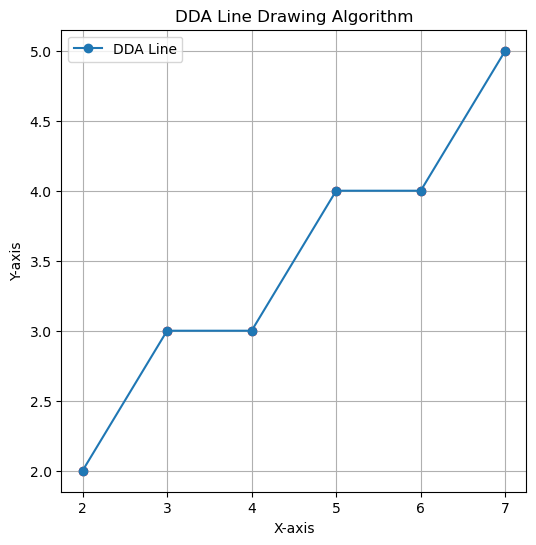

In [2]:
import matplotlib.pyplot as plt
def dda_line(x1, y1, x2, y2):
     # Calculate differences
     dx = x2 - x1
     dy = y2 - y1

     # Determine the number of steps
     steps = max(abs(dx), abs(dy))

     # Calculate increments
     x_increment = dx / steps
     y_increment = dy / steps

     # Initialize starting point
     x, y = x1, y1
     points = [(round(x), round(y))]

     # Generate points along the line
     for _ in range(steps):
         x += x_increment
         y += y_increment
         points.append((round(x), round(y)))

     return points
# Example usage
if __name__ == "__main__":
     # Define endpoints of the line
     x1, y1 = 2, 2
     x2, y2 = 7, 5

     # Get pixel positions using DDA
     points = dda_line(x1, y1, x2, y2)

     # Extract x and y coordinates for plotting
     x_coords, y_coords = zip(*points)

     # Plot the line
     plt.figure(figsize=(6, 6))
     plt.plot(x_coords, y_coords, marker='o', label="DDA Line")
     plt.scatter(x_coords, y_coords, color='red') # Highlight pixel positions
     plt.title("DDA Line Drawing Algorithm")
     plt.xlabel("X-axis")
     plt.ylabel("Y-axis")
     plt.grid(True)
     plt.legend()
     plt.show()

<h2>Question 2. Bresenham’s Line Drawing Algorithm</h2>

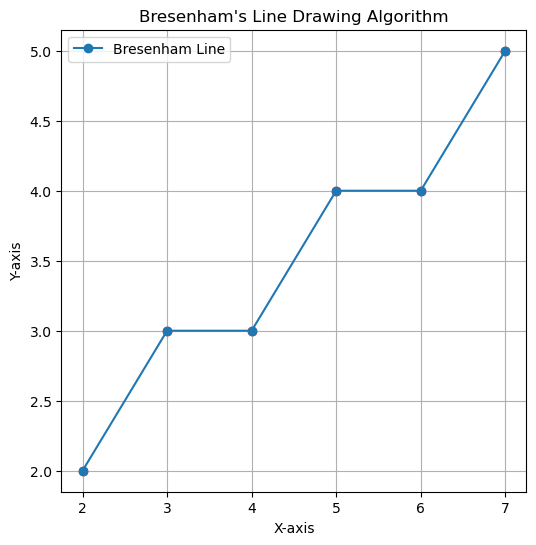

In [5]:
def bresenham_line(x1, y1, x2, y2):
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1

    points = []

    if dx > dy:
        # Shallow slope (x dominates)
        P = 2 * dy - dx
        while x1 != x2:
            points.append((x1, y1))
            if P >= 0:
                y1 += sy
                P -= 2 * dx
            x1 += sx
            P += 2 * dy
    else:
        # Steep slope (y dominates)
        P = 2 * dx - dy
        while y1 != y2:
            points.append((x1, y1))
            if P >= 0:
                x1 += sx
                P -= 2 * dy
            y1 += sy
            P += 2 * dx

    points.append((x1, y1))  # Add the last point
    return points
        
# Example usage
if __name__ == "__main__":
     # Define endpoints of the line
     x1, y1 = 2, 2
     x2, y2 = 7, 5

     # Get pixel positions using Bresenham's algorithm
     points = bresenham_line(x1, y1, x2, y2)

     # Extract x and y coordinates for plotting
     x_coords, y_coords = zip(*points)

     # Plot the line
     plt.figure(figsize=(6, 6))
     plt.plot(x_coords, y_coords, marker='o', label="Bresenham Line")
     plt.scatter(x_coords, y_coords, color='red') # Highlight pixel positions
     plt.title("Bresenham's Line Drawing Algorithm")
     plt.xlabel("X-axis")
     plt.ylabel("Y-axis")
     plt.grid(True)
     plt.legend()
     plt.show()

<h2>Question 3. Midpoint Circle Algorithm</h2>

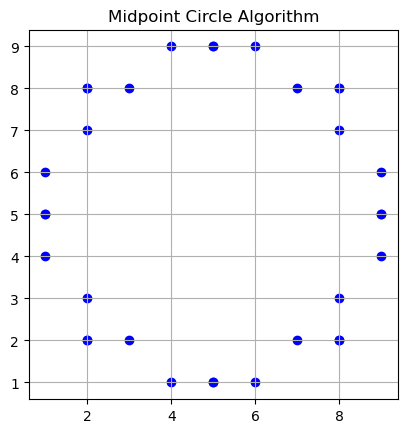

In [6]:
import matplotlib.pyplot as plt

def plot_circle_points(xc, yc, x, y):
     plt.scatter([xc+x, xc-x, xc+x, xc-x, xc+y, xc-y, xc+y, xc-y], [yc+y, yc+y, yc-y, yc-y, yc+x, yc+x, yc-x, yc-x], color='blue')

def midpoint_circle(xc, yc, r):
     x, y = 0, r
     P = 1 - r
     plot_circle_points(xc, yc, x, y)

     while x < y:
         x += 1
         if P < 0:
             P += 2*x + 1
         else:
             y -= 1
             P += 2*(x - y) + 1
         plot_circle_points(xc, yc, x, y)
# Example usage
if __name__ == "__main__":
     xc, yc, r = 5, 5, 4 # Center and radius
     midpoint_circle(xc, yc, r)
     plt.title("Midpoint Circle Algorithm")
     plt.grid(True)
     plt.gca().set_aspect('equal', adjustable='box')
     plt.show()

<h2>Question 4. Midpoint Ellipse Algorithm</h2>

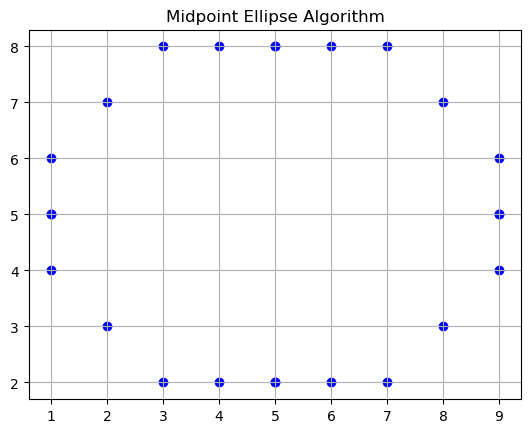

In [7]:
import matplotlib.pyplot as plt

def plot_ellipse_points(xc, yc, x, y):
    plt.scatter([xc+x, xc-x, xc+x, xc-x], [yc+y, yc+y, yc-y, yc-y], color='blue')

def midpoint_ellipse(xc, yc, a, b):
    # Region 1
    x, y = 0, b
    a_sq, b_sq = a**2, b**2
    dx, dy = 0, 2 * a_sq * y
    P1 = b_sq - a_sq * b + 0.25 * a_sq
    while dx < dy:
        plot_ellipse_points(xc, yc, x, y)
        x += 1
        dx += 2 * b_sq
        if P1 < 0:
            P1 += dx + b_sq
        else:
            y -= 1
            dy -= 2 * a_sq
            P1 += dx - dy + b_sq

    # Region 2
    P2 = b_sq * (x + 0.5)**2 + a_sq * (y - 1)**2 - a_sq * b_sq
    while y >= 0:
        plot_ellipse_points(xc, yc, x, y)
        y -= 1
        dy -= 2 * a_sq
        if P2 > 0:
            P2 -= dy + a_sq
        else:
            x += 1
            dx += 2 * b_sq
            P2 += dx - dy + a_sq
# Example usage
if __name__ == "__main__":
    xc, yc, a, b = 5, 5, 4, 3
    midpoint_ellipse(xc, yc, a, b)
    plt.title("Midpoint Ellipse Algorithm")
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

<h2>Question 5. 2D Translation</h2>

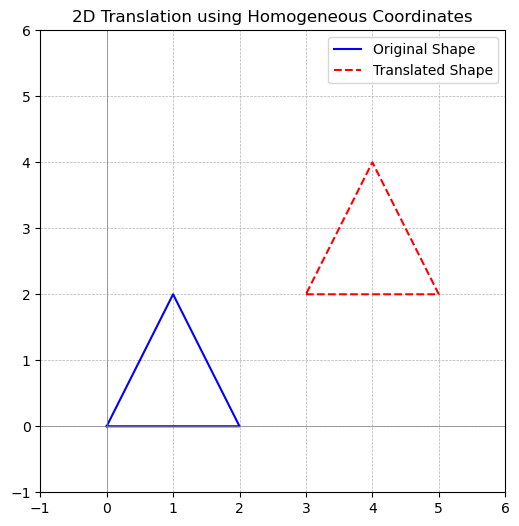

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define translation matrix
def translation_matrix(tx, ty):
    return np.array([[1, 0, tx],[0, 1, ty], [0, 0, 1]])

# Apply transformation to a set of points
def apply_translation(matrix, points):
    homogeneous_points = np.hstack((points, np.ones((points.shape[0], 1)))) # Convert to homogeneous coordinates
    transformed_points = (matrix @ homogeneous_points.T).T # Apply transformation
    return transformed_points[:, :2] # Convert back to Cartesian coordinates

# Define a 2D shape (triangle)
triangle = np.array([[0, 0], [2, 0], [1, 2], [0, 0]]) # Closed shape

# Apply translation
tx, ty = 3, 2 # Translation values
T = translation_matrix(tx, ty)
translated_triangle = apply_translation(T, triangle)

# Plot original and translated shape
plt.figure(figsize=(6,6))
plt.plot(triangle[:, 0], triangle[:, 1], 'b-', label="Original Shape")
plt.plot(translated_triangle[:, 0], translated_triangle[:, 1], 'r--', label="Translated Shape")
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.title("2D Translation using Homogeneous Coordinates")
plt.show()

<h2>Question 6. 2D Scaling in Transformations</h2>

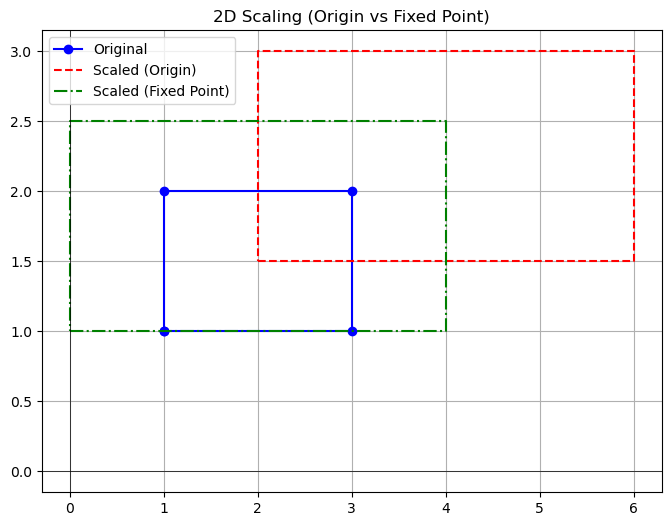

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Define 2D Scaling Matrix
def scaling_matrix(sx, sy):
    return np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]])

# Define Scaling About a Fixed Point
def scaling_about_fixed_point(sx, sy, x0, y0):
    T1 = np.array([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]]) # Translate (-x0, -y0) 

    S = scaling_matrix(sx, sy) # Apply Scaling

    T2 = np.array([[1, 0, x0], [0, 1, y0], [0, 0, 1]]) # Translate back (x0, y0) 

    return T2 @ S @ T1 # Combined transformation matrix

# Define an object (Rectangle: 4 points)
rectangle = np.array([[1, 1, 1], [3, 1, 1], [3, 2, 1], [1, 2, 1], [1, 1, 1]]).T

# Scaling factors
sx, sy = 2, 1.5

# Apply uniform scaling about the origin
T_origin = scaling_matrix(sx, sy)
scaled_rectangle_origin = T_origin @ rectangle

# Apply scaling about fixed point (2, 1)
T_fixed = scaling_about_fixed_point(sx, sy, 2, 1)
scaled_rectangle_fixed = T_fixed @ rectangle

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(rectangle[0], rectangle[1], 'bo-', label="Original")
plt.plot(scaled_rectangle_origin[0], scaled_rectangle_origin[1], 'r--', label="Scaled (Origin)")
plt.plot(scaled_rectangle_fixed[0], scaled_rectangle_fixed[1], 'g-.', label="Scaled (Fixed Point)")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.title("2D Scaling (Origin vs Fixed Point)")
plt.show()

<h2>Question 7. 2D Rotation in Transformations</h2>

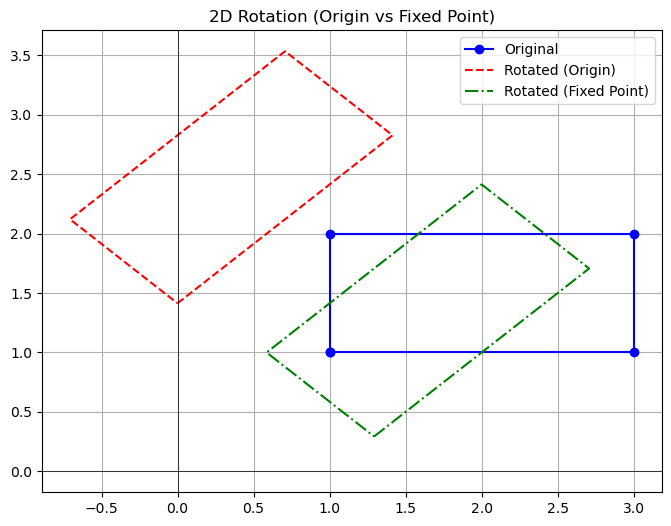

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rotation Matrix
def rotation_matrix(theta):
    rad = np.radians(theta)
    return np.array([[np.cos(rad), -np.sin(rad), 0], [np.sin(rad), np.cos(rad), 0], [0, 0, 1]])
# Define Rotation About a Fixed Point
def rotation_about_fixed_point(theta, x0, y0):
    T1 = np.array([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]]) # Translate (-x0, -y0)

    R = rotation_matrix(theta) # Apply Rotation

    T2 = np.array([[1, 0, x0], [0, 1, y0], [0, 0, 1]])# Translate back (x0, y0)
    
    return T2 @ R @ T1 # Combined transformation matrix

# Define an object (Rectangle: 4 points)
rectangle = np.array([[1, 1, 1], [3, 1, 1], [3, 2, 1], [1, 2, 1], [1, 1, 1]]).T

# Rotation Angle
theta = 45

# Apply Rotation About the Origin
T_origin = rotation_matrix(theta)
rotated_rectangle_origin = T_origin @ rectangle

# Apply Rotation About Fixed Point (2,1)
T_fixed = rotation_about_fixed_point(theta, 2, 1)
rotated_rectangle_fixed = T_fixed @ rectangle

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(rectangle[0], rectangle[1], 'bo-', label="Original")
plt.plot(rotated_rectangle_origin[0], rotated_rectangle_origin[1], 'r--', label="Rotated (Origin)")
plt.plot(rotated_rectangle_fixed[0], rotated_rectangle_fixed[1], 'g-.', label="Rotated (Fixed Point)")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.title("2D Rotation (Origin vs Fixed Point)")
plt.show()

<h2>Question 8. 2D Shearing Transformation</h2>

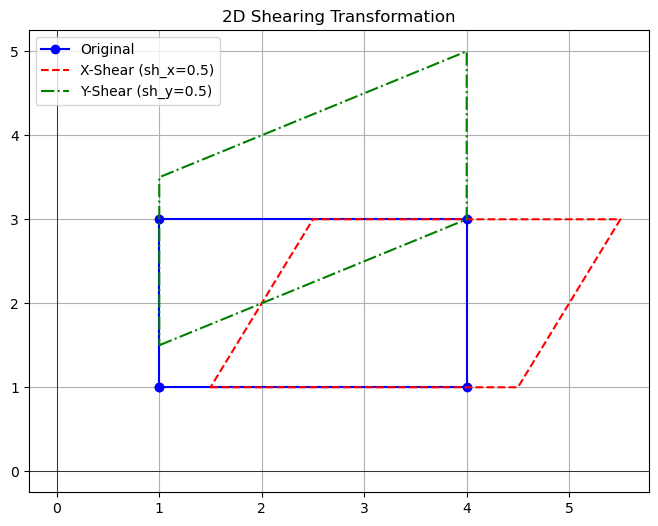

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Define Shearing Matrices
def shear_x_matrix(sh_x):
    return np.array([[1, sh_x, 0], [0, 1, 0], [0, 0, 1]])

def shear_y_matrix(sh_y):
    return np.array([[1, 0, 0], [sh_y, 1, 0], [0, 0, 1]])

# Define an object (Rectangle)
rectangle = np.array([[1, 1, 1], [4, 1, 1], [4, 3, 1], [1, 3, 1], [1, 1, 1]]).T

# Shearing Factors
sh_x = 0.5 # X-Shear factor
sh_y = 0.5 # Y-Shear factor

# Apply Shearing
sheared_x = shear_x_matrix(sh_x) @ rectangle
sheared_y = shear_y_matrix(sh_y) @ rectangle

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(rectangle[0], rectangle[1], 'bo-', label="Original")
plt.plot(sheared_x[0], sheared_x[1], 'r--', label=f"X-Shear (sh_x={sh_x})")
plt.plot(sheared_y[0], sheared_y[1], 'g-.', label=f"Y-Shear (sh_y={sh_y})")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.title("2D Shearing Transformation")
plt.show()

<h2>Question 9. 3D Translation</h2>

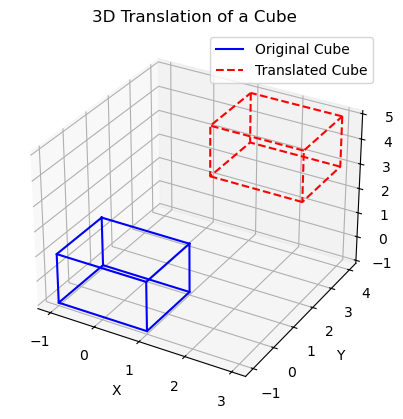

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define a 3D cube vertices
cube = np.array([
    [1, 1, 1, 1], # vertex 1
    [1, 1, -1, 1], # vertex 2
    [1, -1, 1, 1], # vertex 3
    [1, -1, -1, 1],# vertex 4
    [-1, 1, 1, 1], # vertex 5
    [-1, 1, -1, 1],# vertex 6
    [-1, -1, 1, 1],# vertex 7
    [-1, -1, -1, 1] # vertex 8
]).T

# Define 3D Translation Matrix
def translation_matrix(t_x, t_y, t_z):
    return np.array([ [1, 0, 0, t_x], [0, 1, 0, t_y], [0, 0, 1, t_z], [0, 0, 0, 1]])

# Apply translation to the cube
t_x, t_y, t_z = 2, 3, 4 # Translation values

trans_matrix = translation_matrix(t_x, t_y, t_z)
translated_cube = trans_matrix @ cube

# Plotting the original and translated cubes
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Original cube
ax.plot3D(cube[0, [0, 1, 3, 2, 0]], cube[1, [0, 1, 3, 2, 0]], cube[2, [0, 1, 3, 2, 0]], 'b-', label="Original Cube")
ax.plot3D(cube[0, [4, 5, 7, 6, 4]], cube[1, [4, 5, 7, 6, 4]], cube[2, [4, 5, 7, 6, 4]], 'b-')
ax.plot3D([cube[0, 0], cube[0, 4]], [cube[1, 0], cube[1, 4]], [cube[2, 0], cube[2, 4]], 'b-')
ax.plot3D([cube[0, 1], cube[0, 5]], [cube[1, 1], cube[1, 5]], [cube[2, 1], cube[2, 5]], 'b-')
ax.plot3D([cube[0, 2], cube[0, 6]], [cube[1, 2], cube[1, 6]], [cube[2, 2], cube[2, 6]], 'b-')
ax.plot3D([cube[0, 3], cube[0, 7]], [cube[1, 3], cube[1, 7]], [cube[2, 3], cube[2, 7]], 'b-')

# Translated cube
ax.plot3D(translated_cube[0, [0, 1, 3, 2, 0]], translated_cube[1, [0, 1, 3, 2, 0]], translated_cube[2, [0, 1, 3, 2, 0]], 'r--', label="Translated Cube")
ax.plot3D(translated_cube[0, [4, 5, 7, 6, 4]], translated_cube[1, [4, 5, 7, 6, 4]], translated_cube[2, [4, 5, 7, 6, 4]], 'r--')
ax.plot3D([translated_cube[0, 0], translated_cube[0, 4]], [translated_cube[1, 0], translated_cube[1, 4]], [translated_cube[2, 0], translated_cube[2, 4]], 'r--')
ax.plot3D([translated_cube[0, 1], translated_cube[0, 5]], [translated_cube[1, 1], translated_cube[1, 5]], [translated_cube[2, 1], translated_cube[2, 5]], 'r--')
ax.plot3D([translated_cube[0, 2], translated_cube[0, 6]], [translated_cube[1, 2], translated_cube[1, 6]], [translated_cube[2, 2], translated_cube[2, 6]], 'r--')
ax.plot3D([translated_cube[0, 3], translated_cube[0, 7]], [translated_cube[1, 3], translated_cube[1, 7]], [translated_cube[2, 3], translated_cube[2, 7]], 'r--')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("3D Translation of a Cube")
ax.legend()
plt.show()

<h2>Question 10. 3D Rotation (About the Z-Axis)</h2>

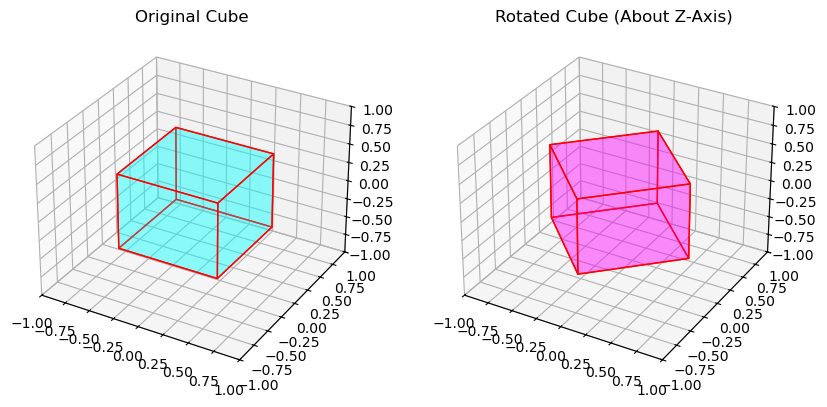

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Define the vertices of a unit cube centered at the origin
vertices = np.array([
    [-0.5, -0.5, -0.5], # Bottom-left-back
    [ 0.5, -0.5, -0.5], # Bottom-right-back
    [ 0.5, 0.5, -0.5], # Top-right-back
    [-0.5, 0.5, -0.5], # Top-left-back
    [-0.5, -0.5, 0.5], # Bottom-left-front
    [ 0.5, -0.5, 0.5], # Bottom-right-front
    [ 0.5, 0.5, 0.5], # Top-right-front
    [-0.5, 0.5, 0.5] # Top-left-front
    ])

# Define the faces of the cube using vertex indices
faces = [
    [vertices[0], vertices[1], vertices[2], vertices[3]], # Back face
    [vertices[4], vertices[5], vertices[6], vertices[7]], # Front face
    [vertices[0], vertices[1], vertices[5], vertices[4]], # Bottom face
    [vertices[2], vertices[3], vertices[7], vertices[6]], # Top face
    [vertices[0], vertices[3], vertices[7], vertices[4]], # Left face
    [vertices[1], vertices[2], vertices[6], vertices[5]]] # Right face
    
# Function to apply rotation transformation about the z-axis
def rotate_z(vertices, theta):
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta), np.cos(theta), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]])
    
    # Add homogeneous coordinate (w=1) to vertices
    vertices_homogeneous = np.hstack([vertices, np.ones((vertices.shape[0], 1))])
    
    # Apply rotation
    rotated_vertices = (rotation_matrix @ vertices_homogeneous.T).T
    
    # Remove homogeneous coordinate
    return rotated_vertices[:, :3]

# Apply rotation about the z-axis
rotated_vertices = rotate_z(vertices, theta=np.pi/4) # Rotate by 45 degrees

# Update faces with rotated vertices
rotated_faces = [
    [rotated_vertices[0], rotated_vertices[1], rotated_vertices[2], rotated_vertices[3]],
    [rotated_vertices[4], rotated_vertices[5], rotated_vertices[6], rotated_vertices[7]],
    [rotated_vertices[0], rotated_vertices[1], rotated_vertices[5], rotated_vertices[4]],
    [rotated_vertices[2], rotated_vertices[3], rotated_vertices[7], rotated_vertices[6]],
    [rotated_vertices[0], rotated_vertices[3], rotated_vertices[7], rotated_vertices[4]],
    [rotated_vertices[1], rotated_vertices[2], rotated_vertices[6], rotated_vertices[5]]
    ]

# Plot original and rotated cubes
fig = plt.figure(figsize=(10, 5))

# Original cube
ax1 = fig.add_subplot(121, projection='3d')
ax1.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='r', alpha=.25))
ax1.set_title("Original Cube")
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_zlim(-1, 1)

# Rotated cube
ax2 = fig.add_subplot(122, projection='3d')
ax2.add_collection3d(Poly3DCollection(rotated_faces, facecolors='magenta', linewidths=1,
edgecolors='r', alpha=.25))
ax2.set_title("Rotated Cube (About Z-Axis)")
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_zlim(-1, 1)
plt.show()

<h2>Question 11. Perspective Projection vs. Orthographic Projection</h2>

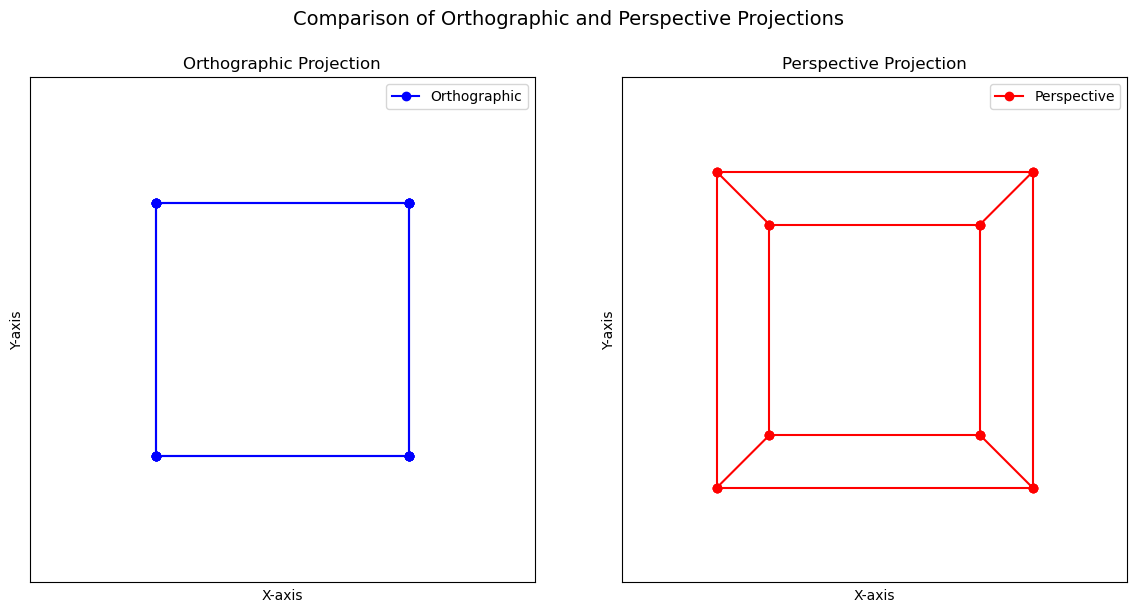

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def orthographic_projection(points):
    """Simple orthographic projection: Drop the Z component."""
    return points[:, :2]
def perspective_projection(points, d=5):
    """Simple perspective projection with focal length d."""
    epsilon = 1e-6 # Avoid division by zero
    projected = np.zeros((points.shape[0], 2))
    for i, (x, y, z) in enumerate(points):
        projected[i, 0] = x / (1 + z / d + epsilon)
        projected[i, 1] = y / (1 + z / d + epsilon)
    return projected

# Define cube vertices
cube_vertices = np.array([
    [-1, -1, -1], [1, -1, -1], [1, 1, -1], [-1, 1, -1], # Back face
    [-1, -1, 1], [1, -1, 1], [1, 1, 1], [-1, 1, 1] # Front face
    ])

# Define cube edges
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0), # Back face
    (4, 5), (5, 6), (6, 7), (7, 4), # Front face
    (0, 4), (1, 5), (2, 6), (3, 7) # Connections between faces
    ]

# Project points
ortho_proj = orthographic_projection(cube_vertices)
persp_proj = perspective_projection(cube_vertices, d=5)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# Orthographic Projection Plot

axs[0].set_title("Orthographic Projection")
for edge in edges:
    p1, p2 = ortho_proj[edge[0]], ortho_proj[edge[1]]
    axs[0].plot([p1[0], p2[0]], [p1[1], p2[1]], 'bo-', label="Orthographic" if edge == edges[0] else "")
    axs[0].legend(loc="upper right")
    
# Perspective Projection Plot
axs[1].set_title("Perspective Projection")
for edge in edges:
    p1, p2 = persp_proj[edge[0]], persp_proj[edge[1]]
    axs[1].plot([p1[0], p2[0]], [p1[1], p2[1]], 'ro-', label="Perspective" if edge == edges[0] else "")
    axs[1].legend(loc="upper right")

# Formatting
for ax in axs:
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
# Add a super title
fig.suptitle("Comparison of Orthographic and Perspective Projections", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to fit the super title
plt.show()